McKinley Martin

This script will explain how to create a smooth distribution curve in Python using a list of numerical values. The data cleaning portion will look just like the function in the scatter plot script, but the plotting is a little trickier. 

# Imports

Start once again by running your imports. This time, we will be using stats from scipy which is helpful for statistical analyses and distributions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Data Preparation

The data cleaning function for this script is exactly the same as the one we used to create the scatter plot. It takes in one file as an argument and returns two numerical lists as a tuple: one for pH and one for salinity. 

In [2]:
def clean_data(filename):
    # initialize lists for pH and salinity values
    pH_values = []
    salinity_values = []
    # read in file
    file = open(filename, "r")
    # iterate over each line in the file, separate data points by comma
    for line in file:
        data_point = line.strip().split(",")
        # ignore lines with no data for one or both values
        if "ND" not in data_point:
            # append pH values to list as floats
            if data_point[1] != "pH":
                pH_values.append(float(data_point[1]))
            # append salinity values to list as floats
            if data_point[2] != "Salinity_dS_m":
                salinity_values.append(float(data_point[2]))
    return pH_values, salinity_values

# Plotting

Now, we can write the script for the plot. This time, we employ stats.gaussian_kde which represents a kernel-density estimate using Gaussian kernels. This script takes in a list of numerical values and an x-axis label string as argument to create the plot: I chose not to write the specific x-label into the script so that I can create the pH and salinity distribution plots in the same run. 

In [3]:
def create_plot(data_list, x_label):
    # create an array of the data list
    data = np.array(data_list)
    # create smooth distribution curve 
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 200)
    plt.plot(x, kde(x), color='darkred', linewidth=2, label='KDE')
    plt.plot(x, kde(x), color='darkred', linewidth=2)
    plt.fill_between(x, kde(x), alpha=0.3, color='steelblue')
    # label axes and show plot
    plt.xlabel(x_label)
    plt.ylabel("Density")
    plt.show()

# Main Function

The main function remains relatively simple, but this time I will be calling the create_plot function twice in the same run to simultaneously make both plots. 

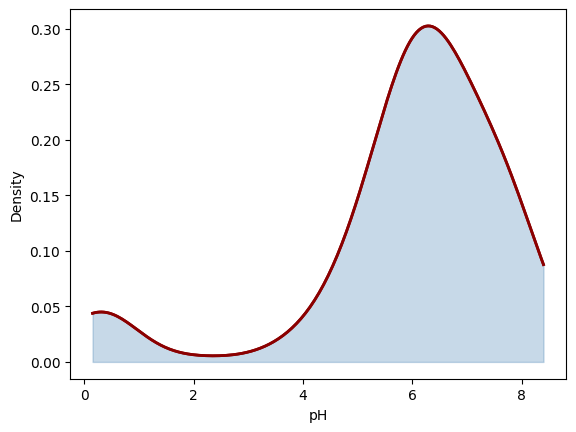

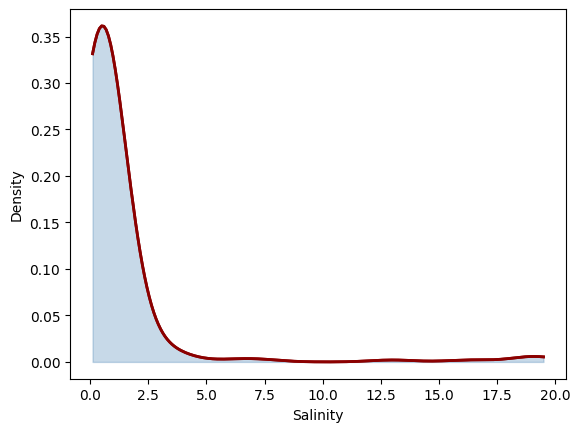

In [4]:
def main():
    pH_values, salinity_values = clean_data("SoilChem_NMDS.csv")
    create_plot(pH_values, "pH")
    create_plot(salinity_values, "Salinity")

main()